Choose Wine Quality CSV file:


Saving WineQT.csv to WineQT.csv

First 5 Rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4   

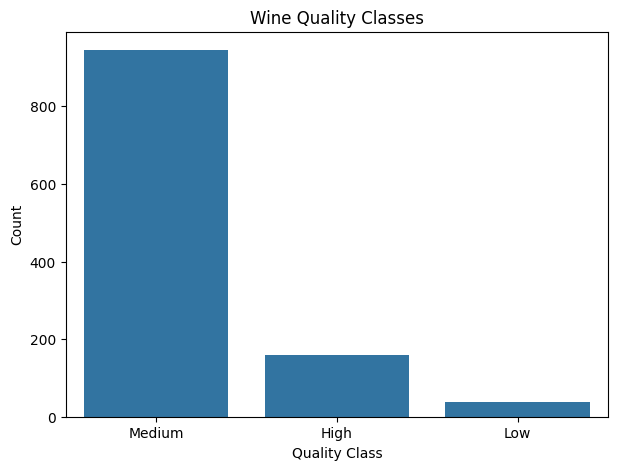


Features:
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    ph  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  id  
0      9.4   0  
1      9.8   1  
2      9.8   2  
3      

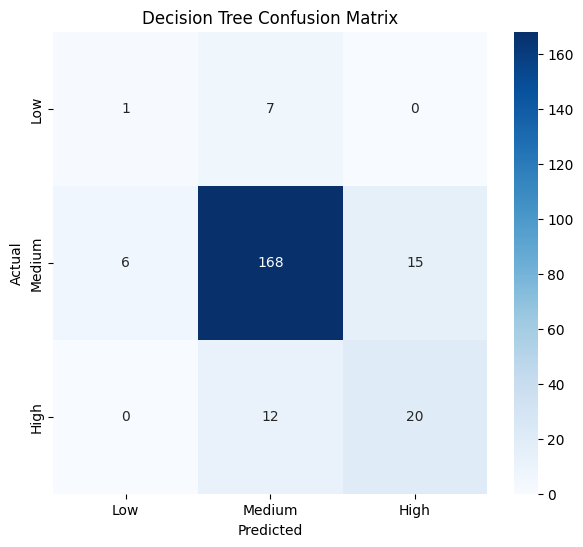


Decision Tree Feature Importance:
                 Feature  Importance
10               alcohol    0.280210
1       volatile_acidity    0.129996
2            citric_acid    0.114959
9              sulphates    0.093570
6   total_sulfur_dioxide    0.061771
8                     ph    0.060696
11                    id    0.060429
0          fixed_acidity    0.054884
4              chlorides    0.048570
7                density    0.047732
3         residual_sugar    0.047183
5    free_sulfur_dioxide    0.000000

RANDOM FOREST RESULTS
Accuracy : 0.8646288209606987
Precision: 0.832759489418878
Recall   : 0.8646288209606987
F1 Score : 0.8304706453178069

Random Forest Classification Report:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         8
      Medium       0.87      0.99      0.92       189
        High       0.85      0.34      0.49        32

    accuracy                           0.86       229
   macro avg       0.57      0.4

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

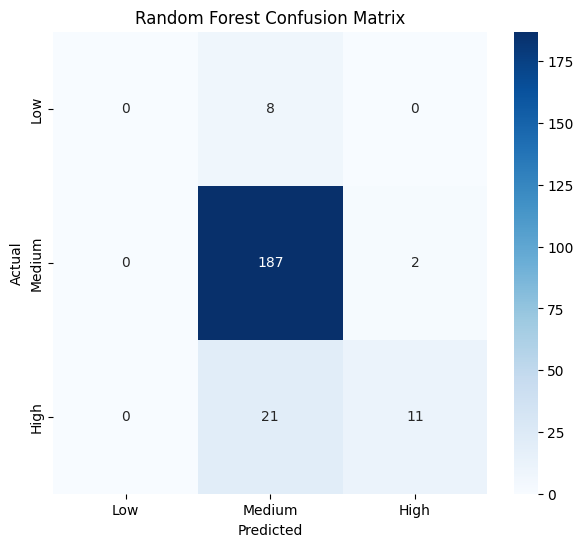


Random Forest Feature Importance:
                 Feature  Importance
10               alcohol    0.175762
1       volatile_acidity    0.155290
2            citric_acid    0.103868
9              sulphates    0.101680
7                density    0.089382
6   total_sulfur_dioxide    0.066087
0          fixed_acidity    0.062673
11                    id    0.057803
8                     ph    0.056884
4              chlorides    0.052769
3         residual_sugar    0.045259
5    free_sulfur_dioxide    0.032543


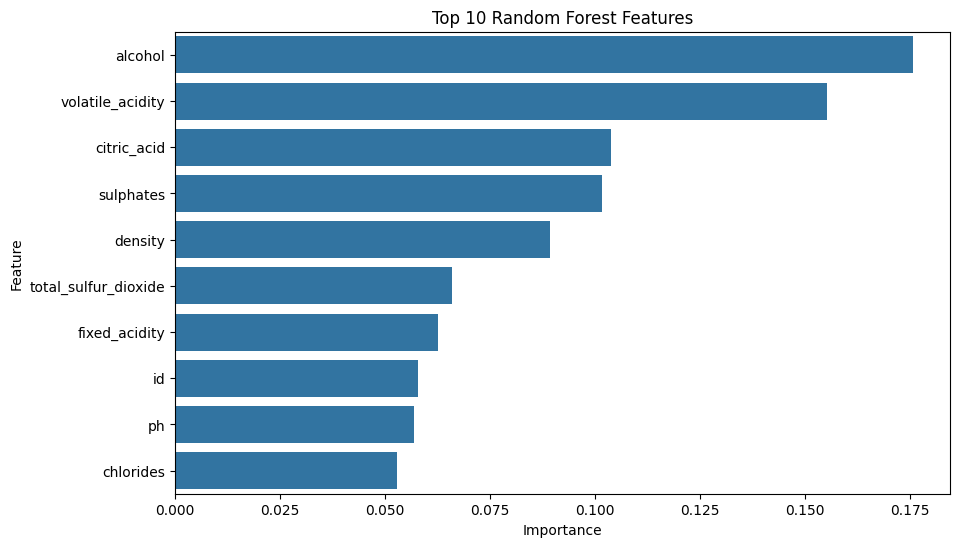


MODEL COMPARISON
           Model  Accuracy  Precision    Recall  F1 Score
0  Decision Tree  0.825328   0.826312  0.825328  0.825610
1  Random Forest  0.864629   0.832759  0.864629  0.830471


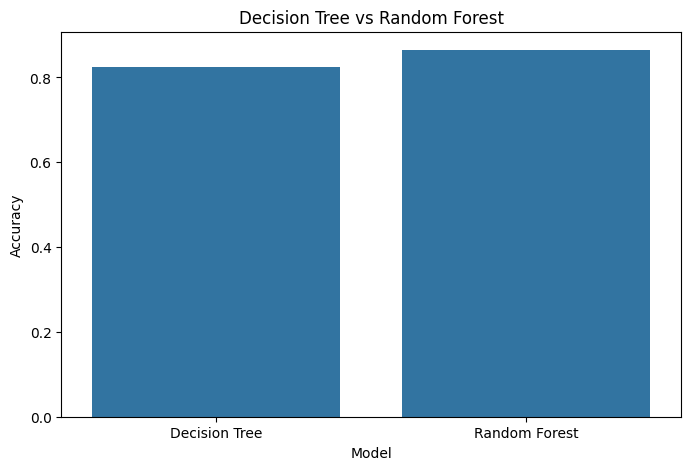


PROGRAM COMPLETED SUCCESSFULLY

Saved files:
1. wine_quality_predictions.csv
2. wine_quality_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================================
# PROGRAM 11: WINE QUALITY
# DECISION TREE AND RANDOM FOREST CLASSIFICATION
# ============================================================

# ============================================================
# 1. Import libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 2. Upload CSV file
# ============================================================

print("Choose Wine Quality CSV file:")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

# ============================================================
# 3. Display dataset
# ============================================================

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

# ============================================================
# 4. Clean column names
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("\nCleaned Columns:")
print(df.columns.tolist())

# ============================================================
# 5. Dataset Information
# ============================================================

print("\nDataset Information:")
df.info()

# ============================================================
# 6. Check missing values
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# 7. Handle missing values
# ============================================================

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(
        df[col].median()
    )

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ============================================================
# 8. Remove duplicate rows
# ============================================================

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df = df.drop_duplicates()

# ============================================================
# 9. Check Wine Quality
# ============================================================

print("\nOriginal Wine Quality Distribution:")
print(df["quality"].value_counts().sort_index())

# ============================================================
# 10. Convert quality into classes
# ============================================================

def quality_class(value):

    if value <= 4:
        return "Low"

    elif value <= 6:
        return "Medium"

    else:
        return "High"


df["quality_class"] = df["quality"].apply(
    quality_class
)

print("\nNew Quality Classes:")
print(
    df["quality_class"].value_counts()
)

# ============================================================
# 11. Plot Quality Distribution
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="quality_class"
)

plt.title("Wine Quality Classes")
plt.xlabel("Quality Class")
plt.ylabel("Count")

plt.show()

# ============================================================
# 12. Separate Features and Target
# ============================================================

X = df.drop(
    ["quality", "quality_class"],
    axis=1
)

y = df["quality_class"]

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

# ============================================================
# 13. Encode Target
# ============================================================

target_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

y = y.map(
    target_mapping
)

print("\nEncoded Target:")
print(y.value_counts())

# ============================================================
# 14. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:")
print(X_train.shape)

print("\nTesting Shape:")
print(X_test.shape)

# ============================================================
# 15. DECISION TREE
# ============================================================

decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

# Train
decision_tree.fit(
    X_train,
    y_train
)

# Prediction
dt_pred = decision_tree.predict(
    X_test
)

# ============================================================
# 16. Decision Tree Evaluation
# ============================================================

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

dt_precision = precision_score(
    y_test,
    dt_pred,
    average="weighted"
)

dt_recall = recall_score(
    y_test,
    dt_pred,
    average="weighted"
)

dt_f1 = f1_score(
    y_test,
    dt_pred,
    average="weighted"
)

print("\n======================================")
print("DECISION TREE RESULTS")
print("======================================")

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

# ============================================================
# 17. Decision Tree Classification Report
# ============================================================

print("\nDecision Tree Classification Report:")

print(
    classification_report(
        y_test,
        dt_pred,
        target_names=[
            "Low",
            "Medium",
            "High"
        ]
    )
)

# ============================================================
# 18. Decision Tree Confusion Matrix
# ============================================================

dt_cm = confusion_matrix(
    y_test,
    dt_pred
)

print("\nDecision Tree Confusion Matrix:")
print(dt_cm)

plt.figure(figsize=(7, 6))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    yticklabels=[
        "Low",
        "Medium",
        "High"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

# ============================================================
# 19. Decision Tree Feature Importance
# ============================================================

dt_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        decision_tree.feature_importances_

})

dt_importance = dt_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nDecision Tree Feature Importance:")
print(dt_importance)

# ============================================================
# 20. RANDOM FOREST
# ============================================================

random_forest = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=5,
    random_state=42
)

# Train
random_forest.fit(
    X_train,
    y_train
)

# Prediction
rf_pred = random_forest.predict(
    X_test
)

# ============================================================
# 21. Random Forest Evaluation
# ============================================================

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

print("\n======================================")
print("RANDOM FOREST RESULTS")
print("======================================")

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

# ============================================================
# 22. Random Forest Classification Report
# ============================================================

print("\nRandom Forest Classification Report:")

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=[
            "Low",
            "Medium",
            "High"
        ]
    )
)

# ============================================================
# 23. Random Forest Confusion Matrix
# ============================================================

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print("\nRandom Forest Confusion Matrix:")
print(rf_cm)

plt.figure(figsize=(7, 6))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    yticklabels=[
        "Low",
        "Medium",
        "High"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

# ============================================================
# 24. Random Forest Feature Importance
# ============================================================

rf_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        random_forest.feature_importances_

})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nRandom Forest Feature Importance:")
print(rf_importance)

# ============================================================
# 25. Plot Random Forest Feature Importance
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Random Forest Features"
)

plt.show()

# ============================================================
# 26. Compare Both Models
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        dt_accuracy,
        rf_accuracy
    ],

    "Precision": [
        dt_precision,
        rf_precision
    ],

    "Recall": [
        dt_recall,
        rf_recall
    ],

    "F1 Score": [
        dt_f1,
        rf_f1
    ]

})

print("\n======================================")
print("MODEL COMPARISON")
print("======================================")

print(comparison)

# ============================================================
# 27. Accuracy Comparison Plot
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Decision Tree vs Random Forest"
)

plt.ylabel("Accuracy")

plt.show()

# ============================================================
# 28. Save Predictions
# ============================================================

result = X_test.copy()

result["Actual"] = y_test.values

result["Decision_Tree_Predicted"] = dt_pred

result["Random_Forest_Predicted"] = rf_pred

result.to_csv(
    "wine_quality_predictions.csv",
    index=False
)

# ============================================================
# 29. Save Cleaned Dataset
# ============================================================

df.to_csv(
    "wine_quality_cleaned.csv",
    index=False
)

print("\n======================================")
print("PROGRAM COMPLETED SUCCESSFULLY")
print("======================================")

print("\nSaved files:")
print("1. wine_quality_predictions.csv")
print("2. wine_quality_cleaned.csv")

# Download predictions
files.download(
    "wine_quality_predictions.csv"
)